In [22]:
import numpy as np
import pandas as pd
import tensorflow as tf
import keras
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from keras.layers import Dense
from keras.models import Sequential
import matplotlib.pyplot as plt

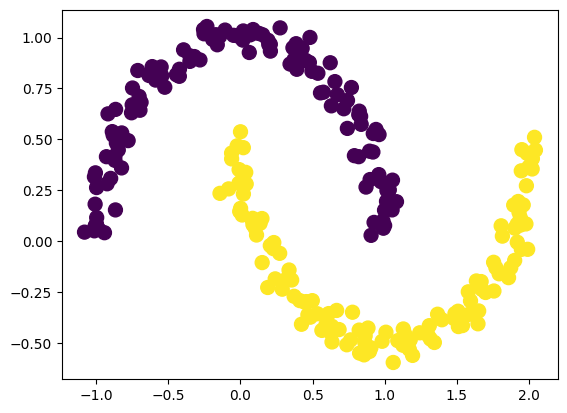

In [23]:
X,y = make_moons(n_samples=250,noise=0.05,random_state=42)
plt.scatter(X[:,0],X[:,1],c=y,s=100)
plt.show()

In [24]:
X

array([[ 8.41540974e-02,  1.13341197e-01],
       [ 1.05091536e+00,  1.54710235e-01],
       [-7.16555269e-01,  6.75607887e-01],
       [ 6.09316755e-02,  9.26542340e-01],
       [-1.00552480e+00,  3.36425155e-01],
       [ 7.63045744e-01, -4.82519400e-01],
       [ 1.30067681e+00, -4.60456076e-01],
       [ 8.93997023e-01, -5.39443631e-01],
       [ 1.01492378e+00,  2.49633435e-01],
       [-8.88621081e-01,  5.38566586e-01],
       [ 1.36613788e+00, -3.56819676e-01],
       [ 1.69872955e+00, -2.50238607e-01],
       [ 1.93909982e+00,  7.98335031e-02],
       [ 1.98164910e+00,  2.73166182e-01],
       [-1.92842298e-01,  9.90722796e-01],
       [ 1.87318667e+00, -1.28604429e-01],
       [ 1.12842503e+00, -4.29068613e-01],
       [ 9.60365014e-01,  5.24004362e-01],
       [ 6.83418960e-01, -4.32057757e-01],
       [ 8.36557987e-01,  5.74232279e-01],
       [ 2.04424212e+00,  4.47864563e-01],
       [ 7.89541222e-01,  4.20628768e-01],
       [-8.99855447e-01,  3.09253977e-01],
       [-1.

In [25]:
model = Sequential()

model.add(Dense(10,activation='sigmoid',input_dim=2))
model.add(Dense(10,activation='sigmoid'))
model.add(Dense(10,activation='sigmoid'))
model.add(Dense(10,activation='sigmoid'))
model.add(Dense(10,activation='sigmoid'))
model.add(Dense(10,activation='sigmoid'))
model.add(Dense(10,activation='sigmoid'))
model.add(Dense(10,activation='sigmoid'))
model.add(Dense(10,activation='sigmoid'))
model.add(Dense(10,activation='sigmoid'))
model.add(Dense(10,activation='sigmoid'))
model.add(Dense(10,activation='sigmoid'))
model.add(Dense(10,activation='sigmoid'))
model.add(Dense(1,activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [26]:
model.compile(loss='binary_crossentropy',optimizer='Adam',metrics=['accuracy'])

In [27]:
old_weights = model.get_weights()[0]
X_train,X_test,y_train,y_test  = train_test_split(X,y,test_size=0.2,random_state=42)

In [28]:
model.fit(X_train,y_train,epochs=10)

Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 200ms/step - accuracy: 0.5100 - loss: 0.6936
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5100 - loss: 0.6933 
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5100 - loss: 0.6936 
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5100 - loss: 0.6936 
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5100 - loss: 0.6934 
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5100 - loss: 0.6934 
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5100 - loss: 0.6935 
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5100 - loss: 0.6933 
Epoch 9/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5100 - loss: 0.6930 
Epoch 10/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5100 - loss: 0.6929 


In [29]:
new_weights = model.get_weights()[0]

In [30]:
model.optimizer.get_config()['learning_rate']

0.0010000000474974513

In [31]:
gradient = (old_weights-new_weights)/ 0.001
percent_change = abs(100*(old_weights - new_weights)/old_weights)

In [32]:
gradient

array([[ 0.10216096, -0.01442432,  0.01084804,  0.03018975,  0.06967038,
        -0.04422664, -0.04148483, -0.00822544,  0.10617077, -0.00655651],
       [-0.07805228,  0.01323223, -0.00956468, -0.02488494, -0.05275011,
         0.04013814,  0.03623962,  0.00667572, -0.08039176,  0.00578165]],
      dtype=float32)

In [33]:
percent_change

array([[4.3250561e+00, 2.5572130e-03, 1.8805690e-03, 6.2260032e-03,
        6.0123790e-02, 7.3123039e-03, 6.5287887e-03, 1.3253158e-03,
        1.5071927e-01, 1.0583733e-03],
       [5.9834465e-02, 4.3480569e-03, 3.7001647e-02, 4.9803713e-03,
        1.6632728e-02, 1.3447550e-01, 9.7452831e-03, 1.0127180e-03,
        6.2479127e-02, 9.6876861e-04]], dtype=float32)

## Method to remove gradient vanishing
### 1. Remove hideen layers means not use 10 15 hidden layer use 2 to 3 hidden layers

### 2. Using ReLU Activation function

In [35]:
model1 = Sequential()

model1.add(Dense(10,activation='relu',input_dim=2))
model1.add(Dense(10,activation='relu'))
model1.add(Dense(10,activation='relu'))
model1.add(Dense(10,activation='relu'))
model1.add(Dense(10,activation='relu'))
model1.add(Dense(10,activation='relu'))
model1.add(Dense(10,activation='relu'))
model1.add(Dense(10,activation='relu'))
model1.add(Dense(10,activation='relu'))
model1.add(Dense(10,activation='relu'))
model1.add(Dense(10,activation='relu'))
model1.add(Dense(1,activation='sigmoid'))


model1.compile(loss='binary_crossentropy',optimizer='Adam',metrics=['accuracy'])
old_weights = model1.get_weights()[0]
X_train,X_test,y_train,y_test  = train_test_split(X,y,test_size=0.2,random_state=42)
model1.fit(X_train,y_train,epochs=10)

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 189ms/step - accuracy: 0.5100 - loss: 0.6931
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5100 - loss: 0.6922 
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5100 - loss: 0.6909 
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5100 - loss: 0.6889 
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5100 - loss: 0.6857 
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5100 - loss: 0.6815 
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5100 - loss: 0.6743 
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5100 - loss: 0.6652 
Epoch 9/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5100 - loss: 0.6529 
Epoch 10/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5100 - loss: 0.6350 


In [36]:
new_weights = model.get_weights()[0]
model.optimizer.get_config()['learning_rate']
gradient = (old_weights-new_weights)/ 0.001
percent_change = abs(100*(old_weights - new_weights)/old_weights)

In [37]:
gradient

array([[ -528.27783 ,   280.16385 ,   211.57388 ,  -631.17035 ,
          698.65533 ,  -140.68973 ,   301.5635  ,  -333.13364 ,
          384.53915 , -1151.5128  ],
       [  360.01566 ,  -548.33844 ,    62.153484,  -624.6956  ,
         -371.9348  ,  -234.84071 ,  1013.7686  ,   430.15317 ,
         -415.32883 , -1086.3605  ]], dtype=float32)

In [38]:
percent_change

array([[ 99.535706,  98.688866,  57.920063, 431.4137  , 119.89814 ,
         30.309334,  90.340164, 115.866646, 122.46849 , 216.44295 ],
       [156.76938 , 224.70444 , 171.15707 , 499.71484 , 679.5117  ,
        114.53804 , 157.94136 , 187.80539 ,  76.358696, 221.90446 ]],
      dtype=float32)

### 3. Proper Weight init

### 4.Batch Norm

### 5.Residula Network